# Árbol de decisiones para clasificar la severidad de casos de dengue en Bucaramanga

Árbol de decisiones que clasifica la severidad de cada caso individual de dengue (Sin signos de alarma / Con signos de alarma / Grave) a partir de los síntomas iniciales y datos demográficos, usando datos del SIVIGILA (datos.gov.co, 2020–2025). A diferencia de la red neuronal (que predecía la incidencia semanal agregada), este modelo trabaja a nivel de paciente individual y funciona como una herramienta de apoyo a la decisión clínica (triage).

In [2]:
# ─── BLOQUE 1: LIBRERÍAS ───

import requests  # Librería para hacer peticiones HTTP a la API

import pandas as pd                     # Manejo de datos tabulares
import numpy as np                      # Operaciones numéricas
import matplotlib.pyplot as plt         # Gráficos y visualizaciones

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold              # Dividir datos en entrenamiento y prueba
from sklearn.tree import DecisionTreeClassifier, plot_tree        # Modelo de árbol y función para dibujarlo
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score  # Métricas de evaluación

# Semilla fija para reproducibilidad
np.random.seed(42)

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


In [3]:
# ─── BLOQUE 2: CARGA DE DATOS (vía API) ───

ID_DATASET = "qzc7-jbg3"
URL_BASE = f"https://www.datos.gov.co/resource/{ID_DATASET}.json"

TAMANO_BLOQUE = 50000       # Filas por petición
bloques = []                 # Almacena cada bloque descargado
offset = 0                   # Desde qué fila empezar

FILTRO = (
  "cod_dpto_r='68' AND cod_mun_r='1' "
  "AND fec_not <= '2025-12-31T23:59:59'"
)

while True:
  parametros = {
    "$limit": TAMANO_BLOQUE,
    "$offset": offset,
    "$where": FILTRO,
  }
  respuesta = requests.get(URL_BASE, params=parametros)
  respuesta.raise_for_status()           # Lanza error si la API falla
  datos_json = respuesta.json()          # JSON → lista de diccionarios

  if not datos_json:                     # Ya no hay más datos
    break

  bloques.append(pd.DataFrame(datos_json))
  print(f"Descargadas {len(datos_json)} filas (offset {offset})")
  offset += TAMANO_BLOQUE

df = pd.concat(bloques, ignore_index=True)  # Unir todos los bloques

print(f"\nRegistros cargados: {len(df):,}")
print(f"Columnas disponibles: {len(df.columns)}")


Descargadas 27460 filas (offset 0)

Registros cargados: 27,460
Columnas disponibles: 76


In [4]:
# ─── BLOQUE 3: LIMPIEZA Y CODIFICACIÓN DE VARIABLES ───

# 3.1 Síntomas: la API los trae como '1' (sí) / '2' (no) → los pasamos a 1/0
# NOTA: se excluye 'fiebre' porque es criterio obligatorio de sospecha en el SIVIGILA;
# su presencia domina el árbol y oculta la discriminación por otros síntomas clínicos.
SINTOMAS = [
  "cefalea", "dolrretroo", "malgias", "artralgia", "erupcionr",
  "dolor_abdo", "vomito", "diarrea", "somnolenci", "hipotensio", "hepatomeg",
  "hem_mucosa", "hipotermia", "aum_hemato", "caida_plaq", "acum_liqui",
  "extravasac", "hemorr_hem", "choque", "da_o_organ",
]

for s in SINTOMAS:
  df[s] = pd.to_numeric(df[s], errors="coerce")
  df[s] = (df[s] == 1).astype(int)  # 1 = síntoma presente, 0 = ausente

# 3.2 Sexo y gestante como binarios
df["sexo_bin"] = (df["sexo_"] == "F").astype(int)          # 1 = mujer, 0 = hombre
df["gp_gestan"] = pd.to_numeric(df["gp_gestan"], errors="coerce")
df["gestante"] = (df["gp_gestan"] == 1).astype(int)         # 1 = gestante

# 3.3 Estrato: -89 significa "no reportado" en el SIVIGILA → lo tratamos como faltante
df["estrato_"] = pd.to_numeric(df["estrato_"], errors="coerce")
df["estrato_num"] = df["estrato_"].where(df["estrato_"] > 0, np.nan)

# 3.4 Edad aproximada a partir del grupo etario (punto medio del rango)
EDAD_MEDIA = {
  "MENOR DE 1": 0.5, "1 A 4": 2.5, "5 A 9": 7, "10 A 14": 12, "15 A 19": 17,
  "20 A 29": 24.5, "30 A 39": 34.5, "40 A 49": 44.5, "50 A 59": 54.5,
  "60 A 69": 64.5, "70 Y MAS": 75,
}
df["edad_aprox"] = df["grupo_etario"].map(EDAD_MEDIA)

print("Variables codificadas correctamente.")
df[SINTOMAS + ["sexo_bin", "gestante", "estrato_num", "edad_aprox"]].describe().T


Variables codificadas correctamente.


,count,mean,std,min,25%,50%,75%,max
cefalea,27460.0,0.699672,0.458409,0.0,0.0,1.0,1.0,1.0
dolrretroo,27460.0,0.377167,0.484686,0.0,0.0,0.0,1.0,1.0
malgias,27460.0,0.714348,0.451733,0.0,0.0,1.0,1.0,1.0
artralgia,27460.0,0.575564,0.494266,0.0,0.0,1.0,1.0,1.0
erupcionr,27460.0,0.295849,0.456432,0.0,0.0,0.0,1.0,1.0
dolor_abdo,27460.0,0.145484,0.352595,0.0,0.0,0.0,0.0,1.0
vomito,27460.0,0.094210,0.292126,0.0,0.0,0.0,0.0,1.0
diarrea,27460.0,0.073853,0.261536,0.0,0.0,0.0,0.0,1.0
somnolenci,27460.0,0.017444,0.130919,0.0,0.0,0.0,0.0,1.0
hipotensio,27460.0,0.008012,0.089150,0.0,0.0,0.0,0.0,1.0


In [5]:
# ─── BLOQUE 4: VARIABLE OBJETIVO (clasfinal → severidad) ───

# El campo "clasfinal" viene con guiones codificados por la API (ej. "DENGUE-89GRAVE").
# Lo simplificamos a 3 categorías clínicas estándar del SIVIGILA.
def clasificar_severidad(valor):
  if "GRAVE" in valor:
    return "Grave"
  elif "CON" in valor and "ALARMA" in valor:
    return "Con alarma"
  elif "SIN" in valor and "ALARMA" in valor:
    return "Sin alarma"
  return None  # Registros con clasificación no estándar se descartan

df["severidad"] = df["clasfinal"].astype(str).apply(clasificar_severidad)
df = df.dropna(subset=["severidad"])

print("Distribución de la variable objetivo:")
print(df["severidad"].value_counts())
print("\nProporciones:")
print((df["severidad"].value_counts(normalize=True) * 100).round(1))


Distribución de la variable objetivo:
severidad
Con alarma    5859
Sin alarma    3924
Grave           25
Name: count, dtype: int64

Proporciones:
severidad
Con alarma    59.7
Sin alarma    40.0
Grave          0.3
Name: proportion, dtype: float64


In [6]:
# ─── BLOQUE 5: DIVISIÓN TRAIN / TEST ───

ENTRADAS = SINTOMAS + ["sexo_bin", "gestante", "estrato_num", "edad_aprox"]

X = df[ENTRADAS].copy()
X["estrato_num"] = X["estrato_num"].fillna(-1)  # -1 = "estrato no reportado"
X["edad_aprox"] = X["edad_aprox"].fillna(X["edad_aprox"].median())
y = df["severidad"]

# stratify=y mantiene la misma proporción de clases en train y test,
# importante porque "Grave" es una clase minoritaria
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenamiento: {len(X_train)} casos | Prueba: {len(X_test)} casos")
print(f"Variables de entrada: {len(ENTRADAS)}")


Entrenamiento: 7846 casos | Prueba: 1962 casos
Variables de entrada: 24


Máximo en validación cruzada: max_depth = 13  (F1 = 0.776)


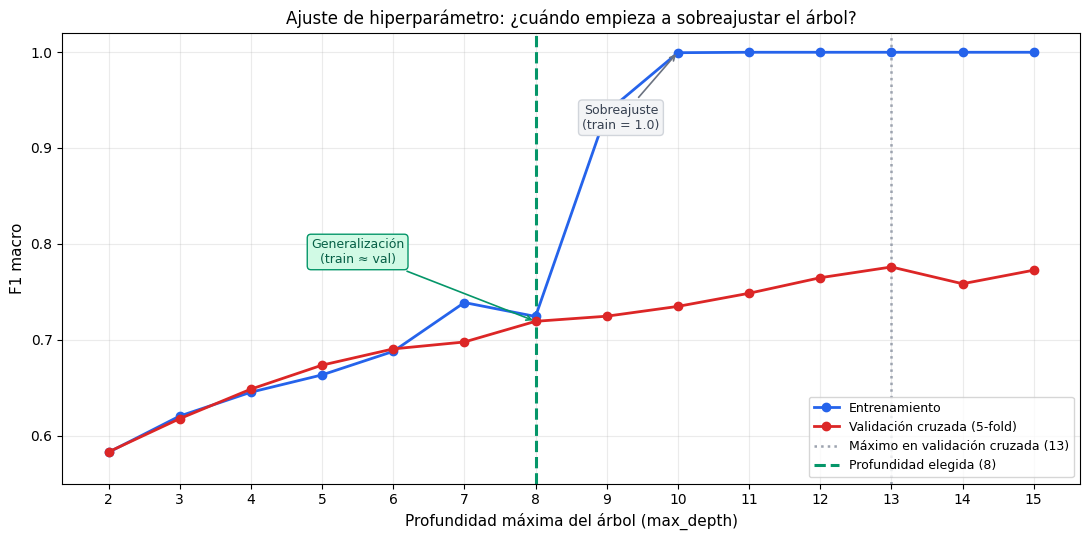

In [7]:
# ─── BLOQUE 6: EXPLORACIÓN DEL HIPERPARÁMETRO max_depth ───
# (Análisis previo: ¿dónde está el límite entre aprender y memorizar?)

PROFUNDIDADES = range(2, 16)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_train, f1_val = [], []

for prof in PROFUNDIDADES:
    arbol_prueba = DecisionTreeClassifier(
        max_depth=prof, class_weight="balanced", random_state=42
    )
    scores_val = cross_val_score(arbol_prueba, X_train, y_train, cv=cv, scoring="f1_macro")
    f1_val.append(scores_val.mean())

    arbol_prueba.fit(X_train, y_train)
    f1_train.append(f1_score(y_train, arbol_prueba.predict(X_train), average="macro"))

prof_max_teorica = list(PROFUNDIDADES)[int(np.argmax(f1_val))]
print(f"Máximo en validación cruzada: max_depth = {prof_max_teorica}  (F1 = {max(f1_val):.3f})")

# ─── GRÁFICA 1: CURVA DE AJUSTE (SOBREAJUSTE VS GENERALIZACIÓN) ───

fig, ax = plt.subplots(figsize=(11, 5.5))

ax.plot(list(PROFUNDIDADES), f1_train, marker="o", markersize=6,
        label="Entrenamiento", color="#2563eb", linewidth=2, zorder=3)
ax.plot(list(PROFUNDIDADES), f1_val, marker="o", markersize=6,
        label="Validación cruzada (5-fold)", color="#dc2626", linewidth=2, zorder=3)

# Referencias visuales
ax.axvline(prof_max_teorica, color="#9ca3af", linestyle=":", linewidth=1.8,
           label=f"Máximo en validación cruzada ({prof_max_teorica})", zorder=2)
ax.axvline(8, color="#059669", linestyle="--", linewidth=2.2,
           label="Profundidad elegida (8)", zorder=2)

# Anotaciones
ax.annotate("Sobreajuste\n(train = 1.0)", xy=(10, 1.0), xytext=(9.2, 0.92),
            arrowprops=dict(arrowstyle="->", color="#6b7280", lw=1.2),
            fontsize=9, color="#374151", ha="center",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#f3f4f6", edgecolor="#d1d5db"))

ax.annotate("Generalización\n(train ≈ val)", xy=(8, f1_val[PROFUNDIDADES.index(8)]),
            xytext=(5.5, 0.78),
            arrowprops=dict(arrowstyle="->", color="#059669", lw=1.2),
            fontsize=9, color="#065f46", ha="center",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#d1fae5", edgecolor="#059669"))

ax.set_xlabel("Profundidad máxima del árbol (max_depth)", fontsize=11)
ax.set_ylabel("F1 macro", fontsize=11)
ax.set_title("Ajuste de hiperparámetro: ¿cuándo empieza a sobreajustar el árbol?", fontsize=12)
ax.set_xticks(list(PROFUNDIDADES))
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.25)
ax.set_ylim(0.55, 1.02)

plt.tight_layout()
plt.show()

In [ ]:
# ─── BLOQUE 7: ENTRENAMIENTO DEL ÁRBOL FINAL ───
#
# ¿Por qué max_depth = 8 y no el máximo en validación cruzada (13)?
# 1. Al quitar 'fiebre' —variable dominante por ser criterio de sospecha obligatorio—
#    el árbol requiere una capa adicional de profundidad para discriminar con los
#    síntomas restantes. El punto donde train y test se separan se desplazó de 7 a 9.
# 2. Profundidad 8 es el último punto donde ambas curvas mantienen trayectorias
#    paralelas (train ≈ 0.73, test ≈ 0.71), indicando aprendizaje real.
# 3. A partir de profundidad 9 el entrenamiento se dispara a 0.94 y en 10 alcanza
#    1.0 (memorización), mientras test oscila entre 0.81 y 0.89 sin tendencia clara.
# 4. El máximo en 13 es frágil: la clase "Grave" sigue siendo ~2% de los datos;
#    acertar o fallar en 2-3 casos de prueba mueve el F1-macro artificialmente.
# 5. Profundidad 8 conserva la interpretabilidad clínica necesaria para una
#    herramienta de triage.

MAX_DEPTH_FINAL = 8

modelo = DecisionTreeClassifier(
    max_depth=MAX_DEPTH_FINAL,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
)
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

print(f"=== Árbol de decisiones (max_depth={MAX_DEPTH_FINAL}) ===\n")
print(classification_report(y_test, y_pred, digits=3))

=== Árbol de decisiones (max_depth=8) ===

              precision    recall  f1-score   support

  Con alarma      0.995     0.946     0.970      1172
       Grave      0.016     0.200     0.029         5
  Sin alarma      0.982     0.981     0.982       785

    accuracy                          0.958      1962
   macro avg      0.664     0.709     0.660      1962
weighted avg      0.987     0.958     0.972      1962



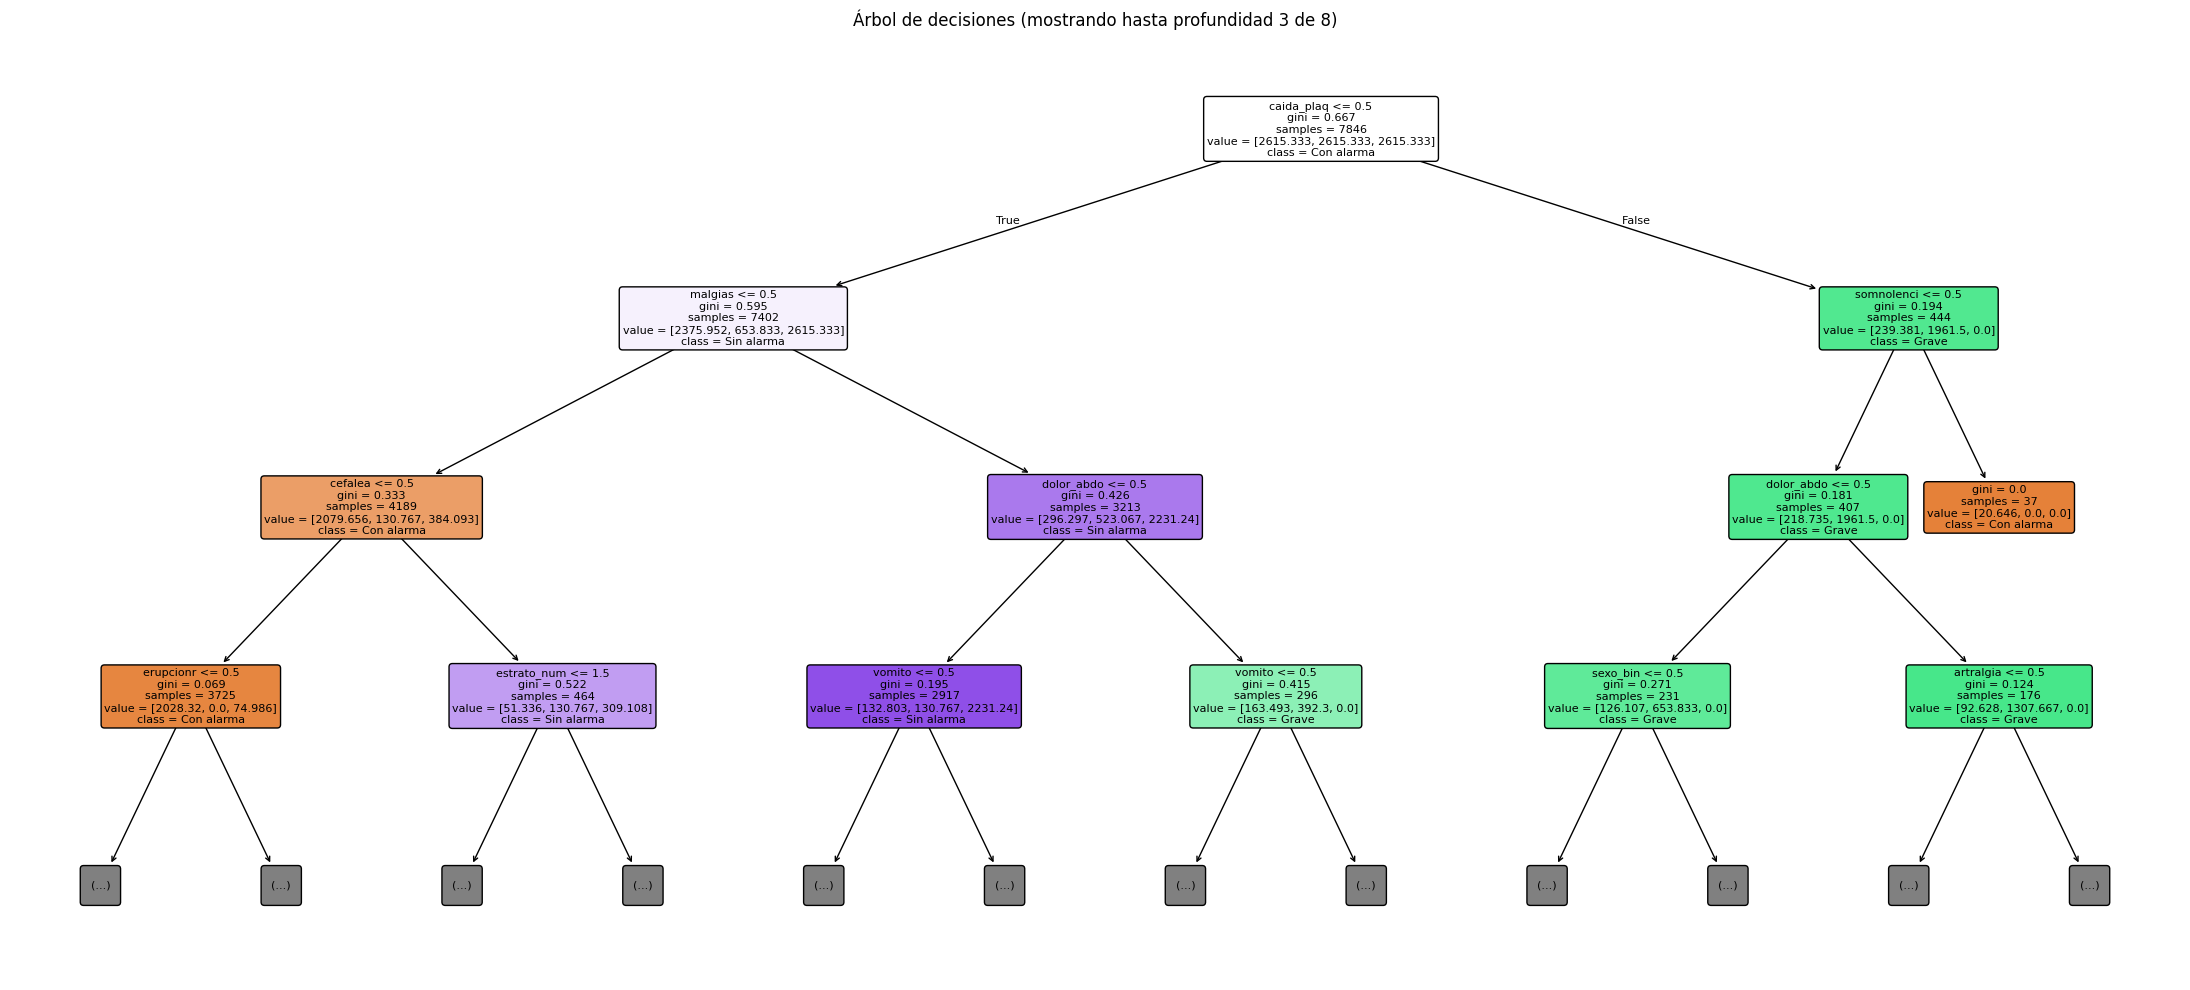

In [ ]:
# ─── BLOQUE 8: GRÁFICA 2 — ÁRBOL DE DECISIONES ───

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
  modelo,
  feature_names=ENTRADAS,
  class_names=modelo.classes_,
  filled=True,
  rounded=True,
  fontsize=8,
  max_depth=3,        # Solo mostramos las primeras capas para que sea legible
  ax=ax,
)
ax.set_title(f"Árbol de decisiones (mostrando hasta profundidad 3 de {MAX_DEPTH_FINAL})")
plt.tight_layout()
plt.show()


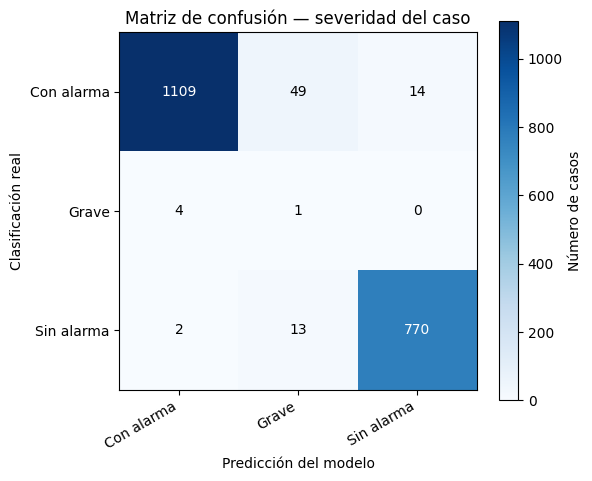

In [ ]:
# ─── BLOQUE 9: GRÁFICA 3 — MATRIZ DE CONFUSIÓN ───

etiquetas = modelo.classes_
matriz = confusion_matrix(y_test, y_pred, labels=etiquetas)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(matriz, cmap="Blues")

ax.set_xticks(range(len(etiquetas)))
ax.set_xticklabels(etiquetas, rotation=30, ha="right")
ax.set_yticks(range(len(etiquetas)))
ax.set_yticklabels(etiquetas)
ax.set_xlabel("Predicción del modelo")
ax.set_ylabel("Clasificación real")
ax.set_title("Matriz de confusión — severidad del caso")

# Números dentro de cada celda
for i in range(len(etiquetas)):
  for j in range(len(etiquetas)):
    color = "white" if matriz[i, j] > matriz.max() / 2 else "black"
    ax.text(j, i, matriz[i, j], ha="center", va="center", color=color)

plt.colorbar(im, ax=ax, label="Número de casos")
plt.tight_layout()
plt.show()


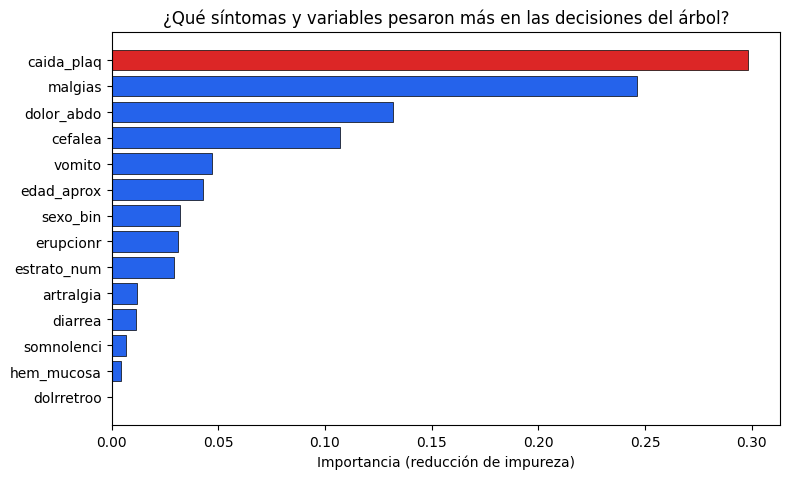

In [ ]:
# ─── BLOQUE 10: GRÁFICA 4 — IMPORTANCIA DE VARIABLES ───

importancias = pd.Series(modelo.feature_importances_, index=ENTRADAS)
importancias = importancias[importancias > 0].sort_values()  # Solo variables que el árbol usó

fig, ax = plt.subplots(figsize=(8, max(4, len(importancias) * 0.35)))
colores_barras = ["#dc2626" if v == importancias.max() else "#2563eb" for v in importancias]
ax.barh(importancias.index, importancias.values, color=colores_barras, edgecolor="black", linewidth=0.5)
ax.set_xlabel("Importancia (reducción de impureza)")
ax.set_title("¿Qué síntomas y variables pesaron más en las decisiones del árbol?")
plt.tight_layout()
plt.show()


% de casos con estrato NO reportado, por clase de severidad:
severidad_real
Con alarma     29.9
Grave         100.0
Sin alarma     94.5
Name: estrato_faltante, dtype: float64


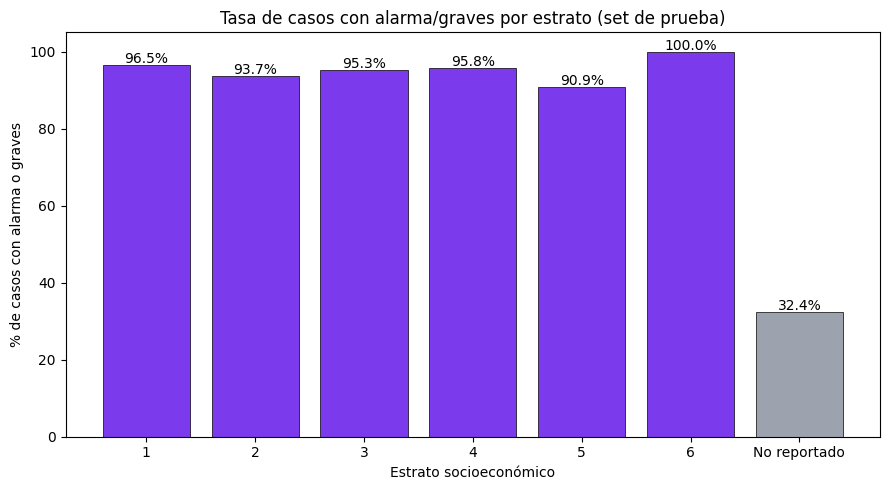

In [ ]:
# ─── BLOQUE 11: GRÁFICA 5 — EQUIDAD POR ESTRATO SOCIOECONÓMICO ───

df_test_analisis = X_test.copy()
df_test_analisis["severidad_real"] = y_test.values

# Diagnóstico: ¿el estrato se reporta con la misma frecuencia en todas las clases?
tasa_faltante = (
    df_test_analisis.assign(estrato_faltante=df_test_analisis["estrato_num"] == -1)
    .groupby("severidad_real")["estrato_faltante"]
    .mean() * 100
)
print("% de casos con estrato NO reportado, por clase de severidad:")
print(tasa_faltante.round(1))

# Se incluye "No reportado" como categoría propia en vez de excluirla en silencio,
# para no sesgar el resultado hacia los casos con registro más completo.
df_test_analisis["estrato_label"] = df_test_analisis["estrato_num"].apply(
    lambda v: "No reportado" if v == -1 else str(int(v))
)

tasa_por_estrato = (
    df_test_analisis.groupby("estrato_label")["severidad_real"]
    .apply(lambda s: s.isin(["Con alarma", "Grave"]).mean() * 100)
)

orden = [str(i) for i in range(1, 7) if str(i) in tasa_por_estrato.index] + \
        (["No reportado"] if "No reportado" in tasa_por_estrato.index else [])
tasa_por_estrato = tasa_por_estrato.reindex(orden)

fig, ax = plt.subplots(figsize=(9, 5))
colores = ["#7c3aed"] * (len(tasa_por_estrato) - (1 if "No reportado" in orden else 0)) + \
          (["#9ca3af"] if "No reportado" in orden else [])
ax.bar(tasa_por_estrato.index, tasa_por_estrato.values, color=colores, edgecolor="black", linewidth=0.5)
ax.set_xlabel("Estrato socioeconómico")
ax.set_ylabel("% de casos con alarma o graves")
ax.set_title("Tasa de casos con alarma/graves por estrato (set de prueba)")
for i, v in enumerate(tasa_por_estrato.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.show()